In [2]:
import matplotlib.pyplot as plt
from tqdm import tqdm

from feature_extractor import GeometricFeatureExtractor
from icp import ICP, SigmaAnnealingCallback, MultiStartICP
from matcher import GaussianMatcher
from synthetic import SyntheticExperiment
from utils import convergence_ratio, convergence_to_global_opt_ratio
from visualization import ErrorMetricsVisualizer

plt.style.use('seaborn-v0_8-whitegrid')

MAX_ITER = 200
N_SEEDS = 30
N_STARTS = 13

In [3]:
# 1. MultiICP with appending of geometric features in gaussian matcher
extractor = GeometricFeatureExtractor(k=4)
gaussian_matcher = GaussianMatcher(sigma=1, k=40, feature_extractor=extractor, feature_mode='append', beta=1)
callbacks = [SigmaAnnealingCallback(matcher=gaussian_matcher, sigma_init=4, sigma_final=0.5, anneal_steps=MAX_ITER)]
single_icp = ICP(matcher=gaussian_matcher, callbacks=callbacks, max_iter=MAX_ITER)
icp = MultiStartICP(single_icp, n_starts=N_STARTS)

In [4]:
results = []
ground_truths = []
for seed in tqdm(range(N_SEEDS), desc=f"Running ICP on several seeds"):
    exp = SyntheticExperiment.generate(500, 0.0, 8.0, style="clustered")
    result = icp.fit(exp.P, exp.Q)
    results.append(result)
    ground_truths.append(exp.T_gt)

best_results = [r.best for r in results]

Running ICP on several seeds: 100%|██████████| 30/30 [03:38<00:00,  7.27s/it]


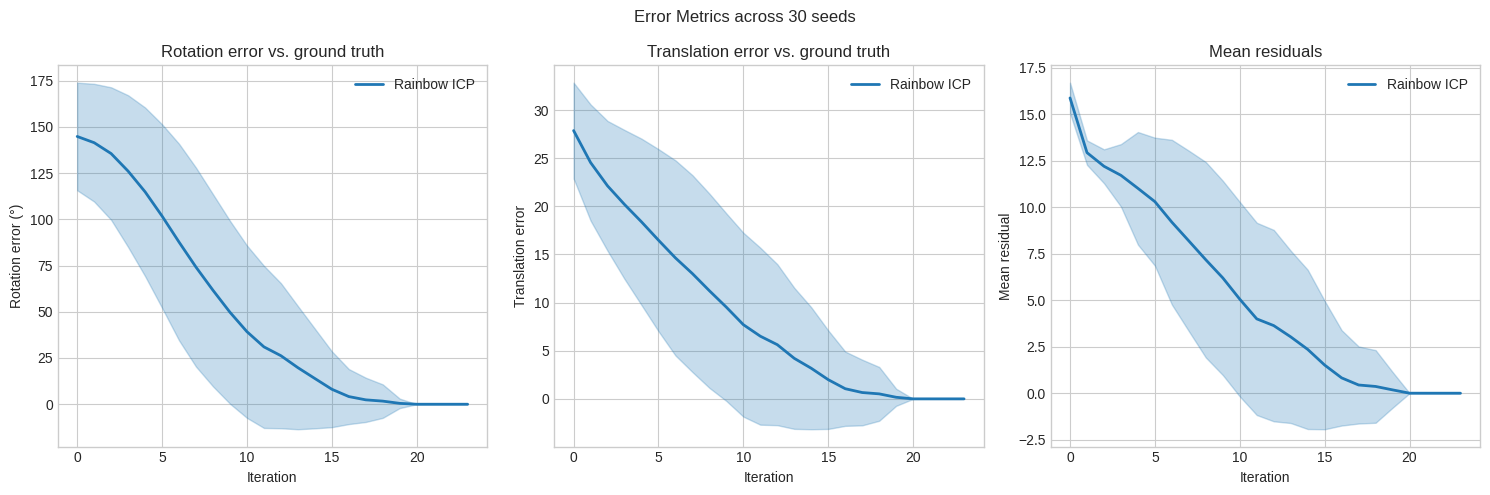

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ErrorMetricsVisualizer.plot_convergence_shaded(axes, [best_results], [ground_truths], ["Rainbow ICP"])
plt.suptitle(f"Error Metrics across {N_SEEDS} seeds")
plt.tight_layout()
plt.savefig('../results/8_rainbow_ICP_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
print(f"Converged for {convergence_ratio(best_results)*100:.2f} of seeds")
print(f"Global optimum found in {convergence_to_global_opt_ratio(best_results, tol=0.1)*100:.2f}% of seeds")

Converged for 100.00 of seeds
Global optimum found in 100.00% of seeds


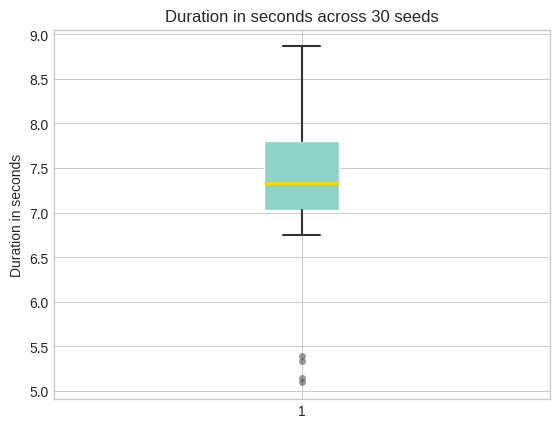

In [7]:
from visualization import _BOX_STYLE

plt.boxplot([r.duration_s for r in results], **dict(_BOX_STYLE))
plt.ylabel("Duration in seconds")
plt.title(f"Duration in seconds across {N_SEEDS} seeds")
plt.savefig('../results/8_rainbow_ICP_time.png', dpi=150, bbox_inches='tight')
plt.show()